In [56]:
# NNSE Function-based Implementation for Tyson Model
# Implements a vector-based mutation and permutation algorithm

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import copy
import time

# ============================================================================
# === CONFIGURATION VARIABLES ===
# ============================================================================

# Simulation settings
N_STEPS = 2500  # Number of mutation steps to run
SIGMA = 0.01  # Standard deviation for Gaussian mutations in normalized space
N_Vec = 50  # Number of bins for binning squared differences
MAX_VALUE = 50.0  # Maximum log value for bin thresholds (logspace goes from 0 to this)
K_INITIAL = int(N_Vec // 50)  # Number of top positions to fill initially (top half)
T_START = 0.0  # Simulation start time
T_END = 500.0  # Simulation end time
N_TIME_POINTS = 501  # Number of time points

# Define bin thresholds using logspace (equally spaced in log space)
# y0, y1, ..., yN_BINS: thresholds for binning
bin_thresholds = np.linspace(0, MAX_VALUE, N_Vec + 1) + MAX_VALUE / N_Vec
  # y0, y1, ..., yN_BINS, basically sets y0 to the value of y1 because function will likely never be zero

# ============================================================================
# === BASE PARAMETERS (p0) ===
# ============================================================================

p0 = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# Parameters to vary
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
]

p0_vec = np.array([p0[name] for name in param_names])
n_params = len(param_names)

# Time evaluation array
t_eval = np.linspace(T_START, T_END, N_TIME_POINTS)

# ============================================================================
# === TYSON MODEL DEFINITION ===
# ============================================================================

CT = p0["CT"]

def F_M(M, p):
    """Helper function for M-dependent rate"""
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def f_rhs(t, x, p):
    """Right-hand side of the ODE system"""
    # x = [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def simulate_at_params(p_local, t_eval):
    """Simulate the ODE system with given parameters"""
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), 
                    (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y

def compute_obs(X):
    """Compute observables: YT/CT and M/CT"""
    if X.ndim == 1:
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT
    else:
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT

# ============================================================================
# === REFERENCE SIMULATION (p0) ===
# ============================================================================

print("Running reference simulation with p0...")
t0, y0 = simulate_at_params(p0, t_eval)
YT0, M0 = compute_obs(y0)
print(f"✓ Reference simulation complete")

# ============================================================================
# === SIM FUNCTION ===
# ============================================================================

def sim(P_vec):
    """
    Simulate with parameter vector P and compute squared difference with p0.
    Returns the squared difference (f(xi) value).
    """
    # Convert parameter vector to dictionary
    p_local = copy.deepcopy(p0)
    for i, name in enumerate(param_names):
        p_local[name] = P_vec[i]
    
    # Run simulation
    try:
        t, y = simulate_at_params(p_local, t_eval)
        YT, M = compute_obs(y)
        
        # Interpolate reference to match time points
        YT0_interp = np.interp(t, t0, YT0)
        M0_interp = np.interp(t, t0, M0)
        
        # Compute squared differences
        diff_YT_sq = (YT - YT0_interp)**2
        diff_M_sq = (M - M0_interp)**2
        
        # Integrate squared differences
        integral_YT_sq = np.trapezoid(diff_YT_sq, t)
        integral_M_sq = np.trapezoid(diff_M_sq, t)
        squared_diff = integral_YT_sq + integral_M_sq
        
        return squared_diff
        
    except Exception as e:
        # If simulation fails, return infinity
        print(f"Warning: Simulation failed: {e}")
        return np.inf

print(f"✓ Configuration complete")
print(f"  Parameters: {param_names}")
print(f"  Number of parameters: {n_params}")
print(f"  Bin thresholds (y0, ..., y{N_Vec}): [{bin_thresholds[0]:.4e}, ..., {bin_thresholds[-1]:.4e}]")


Running reference simulation with p0...
✓ Reference simulation complete
✓ Configuration complete
  Parameters: ['k1_aa_over_CT', 'k3_CT', 'k4', 'k4prime', 'k6', 'k7']
  Number of parameters: 6
  Bin thresholds (y0, ..., y50): [1.0000e+00, ..., 5.1000e+01]


In [57]:
# ============================================================================
# === TYSONFUNC: MUTATION AND PERMUTATION FUNCTION ===
# ============================================================================

def TysonFunc(X_list, fX_list):
    """
    Mutate each parameter vector, evaluate, reject if worse, then permute.
    Also handles filling empty positions: if a swap involved an empty position,
    generates a new point and tries to place it as low as possible.
    
    Args:
        X_list: List of parameter vectors [x0, x1, ..., xn] where each xi is a numpy array (may be None)
        fX_list: List of function values [f(x0), f(x1), ..., f(xn)] (may be None)
    
    Returns:
        v_list: List of parameter vectors after mutation and permutation [v0, v1, ..., vn]
        fv_list: List of function values [f(v0), f(v1), ..., f(vn)]
        fX_prime_list: List of function values after mutation but before permutation [f(x'0), f(x'1), ..., f(x'n)]
        swaps: List of (i, j) tuples indicating which positions were swapped
    """
    n = len(X_list)
    
    # Step 1: Mutate each non-empty xi
    X_prime_list = []
    fX_prime_list = []
    
    for i in range(n):
        xi = X_list[i]
        fxi = fX_list[i]
        
        # Skip empty positions
        if xi is None or fxi is None:
            X_prime_list.append(None)
            fX_prime_list.append(None)
            continue
        
        # Normalize parameters: u_i = p_i / (2 * p0_i) so each lies in [0,1]
        u_vec = xi / (2.0 * p0_vec)
        
        # Apply Gaussian mutation in u-space
        u_mutated = u_vec + np.random.normal(0, SIGMA, size=n_params)
        
        # Wrap around boundaries [0, 1] with periodic boundary conditions
        u_mutated = u_mutated % 1.0
        
        # Map back to parameter space: p_i = 2 * p0_i * u_i
        xi_prime = 2.0 * p0_vec * u_mutated
        
        # Evaluate mutated parameter: f(x'i) := sim(x'i)
        fxi_prime = sim(xi_prime)
        
        # Step 2: Reject x'i if f(x'i) > y_i, otherwise accept
        if fxi_prime > bin_thresholds[i]:
            # Reject: keep original
            X_prime_list.append(xi.copy())
            fX_prime_list.append(fxi)
        else:
            # Accept: use mutated
            X_prime_list.append(xi_prime)
            fX_prime_list.append(fxi_prime)
    
    # Step 3: Permutation step
    # For each position i from n-1 down to 1 (0-indexed: n-1, n-2, ..., 1)
    # If f(x'_i) <= y_{i-1}, swap position i with position i-1

    v_list = X_prime_list.copy()
    fv_list = fX_prime_list.copy()

    # Track which positions were empty BEFORE swaps
    empty_before_swaps = set(i for i in range(n) if v_list[i] is None or fv_list[i] is None)

    # Track swaps
    swaps = []  # List of (i, j) tuples for swaps

    for i in range(n-1, 0, -1):  # i from n-1 down to 1
        # Skip if both positions are empty
        if fv_list[i] is None and fv_list[i-1] is None:
            continue
        
        # If f(x'_i) <= y_{i-1} and position i is not empty, swap
        if fv_list[i] is not None and fv_list[i] <= bin_thresholds[i-1]:
            # Swap position i with position i-1
            if v_list[i] is not None and v_list[i-1] is not None:
                v_list[i], v_list[i-1] = v_list[i-1].copy(), v_list[i].copy()
            else:
                v_list[i], v_list[i-1] = v_list[i-1], v_list[i]
            fv_list[i], fv_list[i-1] = fv_list[i-1], fv_list[i]
            swaps.append((i, i-1))  # Record the swap

    # Step 4: Fill positions that became empty due to swaps
    # Find positions that are empty AFTER swaps but were NOT empty BEFORE swaps
    empty_after_swaps = set(i for i in range(n) if v_list[i] is None or fv_list[i] is None)
    newly_empty_positions = empty_after_swaps - empty_before_swaps

    for empty_pos in newly_empty_positions:
        # Generate a new random point
        max_attempts = 1000
        placed = False
        
        for attempt in range(max_attempts):
            # Generate random point in normalized u-space [0, 1]
            u_random = np.random.uniform(0, 1, size=n_params)
            # Map to parameter space: p_i = 2 * p0_i * u_i
            x_new = 2.0 * p0_vec * u_random
            fx_new = sim(x_new)
            
            # Try to place it in the best (lowest index) position it can fit
            placed = False
            for pos in range(n):
                if fx_new <= bin_thresholds[pos]:
                    # Can place it at position pos (meets threshold y_i)
                    # Only place if position is empty
                    if v_list[pos] is None or fv_list[pos] is None:
                        v_list[pos] = x_new
                        fv_list[pos] = fx_new
                        placed = True
                        break  # Break out of inner loop (for pos)
            
            # Break out of attempt loop if we placed it
            if placed:
                break
            # If we couldn't place it anywhere, try again with a new random point
        
        # Print warning if we failed to place after max_attempts
        if not placed:
            print(f"Warning: Failed to fill empty position {empty_pos} after {max_attempts} attempts")
            # If we couldn't place it anywhere, try again with a new random point
                
    return v_list, fv_list, fX_prime_list, swaps

print("✓ TysonFunc defined")


✓ TysonFunc defined


In [58]:
# ============================================================================
# === SIMULATION LOOP ===
# ============================================================================
# Note: fill_vacancies logic is now integrated into TysonFunc
import time

# Helper function to format f values and y thresholds, handling None
def format_f_vals(fX_list, n):
    """Format f values and y thresholds for printing, handling None values.
    Returns two strings: (f_vals_str, y_vals_str)
    Always shows all f(xi) and y_i values.
    """
    indices = list(range(n))
    f_vals = [fX_list[i] if i < len(fX_list) else None for i in indices]
    f_vals_str = " ".join([f"{fx:<12.3e}" if fx is not None else f"{'---':<12}" for fx in f_vals])
    y_vals_str = " ".join([f"{bin_thresholds[i]:<12.3e}" for i in indices])
    return f_vals_str, y_vals_str

n = N_Vec  # Number of parameter vectors to maintain

print(f"Starting simulation with n={n} parameter vectors for {N_STEPS} steps...")

# Initialize: Only fill worst K positions (highest indices), leave best positions empty (None)
K = K_INITIAL
X_list = [None] * n
fX_list = [None] * n


# Generate K random points in the worst positions (highest indices, highest thresholds)
# Fill positions from n-K to n-1 (e.g., if n=50, K=25, fill positions 25-49)
for idx in range(n-K, n):
    # Generate random point in normalized u-space [0, 1]
    u_random = np.random.uniform(0, 1, size=n_params)
    # Map to parameter space: p_i = 2 * p0_i * u_i
    xi = 2.0 * p0_vec * u_random
    fxi = sim(xi)
    X_list[idx] = xi
    fX_list[idx] = fxi

# Don't sort during initialization - keep filled positions in their original positions (worst positions)
# The sorting will happen naturally through the mutation and swapping process
filled_count = sum(1 for x in X_list if x is not None)
print(f"\nFilled: {filled_count} positions")

# Print y thresholds row once at the top (in italics)
_, y_vals_str = format_f_vals(fX_list, n)  # Get y_vals_str format

print(f"\n✓ Initialization complete ({filled_count} positions filled, {n-filled_count} empty)")

# Storage for tracking
all_X = [[x.copy() if x is not None else None for x in X_list]]
all_fX = [[fx if fx is not None else None for fx in fX_list]]
all_swaps = [[]]  # Store swaps for each step (empty for initial state)

# Progress tracking
print_interval = max(1, int(N_STEPS // 50)) 

# Create table header
# Reordered: Step, #swap, #empty, then all f(xi) values, then time
header_cols = [f"f(x{i})" for i in range(n)]
header = f"{'Step':<6} {'#swap':<6} {'#empty':<7} " + " ".join([f"{col:<12}" for col in header_cols]) + f" {'time':<6}"
separator_len = 6 + 1 + 6 + 1 + 7 + 1 + n * 13 + 1 + 6  # Step + #swap + #empty + n columns + time
print(f"\n{header}")
# Print y thresholds row
y_header_cols = [f"y{i}" for i in range(n)]
y_header = f"{'':<6} {'':<6} {'':<7} " + " ".join([f"{col:<12}" for col in y_header_cols]) + f" {'':<6}"
print(y_header)

# Print y thresholds row once at the top (in italics)
_, y_vals_str = format_f_vals(fX_list, n)  # Get y_vals_str format
print(f"\033[3m{'':<6} {'':<6} {'':<7}  {y_vals_str} {'':<6}\033[0m")  # Italic


# Print initial state
f_vals_str, y_vals_str = format_f_vals(fX_list, n)
empty_count = sum(1 for i in range(len(X_list)) if X_list[i] is None or fX_list[i] is None)
print(f"{'Init':<6} {'0':<6} {empty_count:<7} {f_vals_str} {'0.00':<6}")

BURN_IN = int(0.5*N_STEPS)  # Wait for population to stabilize
swap_count = np.zeros(N_Vec + 1)  # Track swaps at each position
total_opportunities = np.zeros(N_Vec + 1)  # Track total chances to swap
is_burned_in = False

# NEW: Store volume ratio history for convergence analysis
volume_ratio_history = []  # List of (step, volume_ratios) tuples
history_interval = 100  # Save every 100 steps after burn-in

last_print_time = time.time()
for step in range(N_STEPS):
    # Store unmutated state (before mutation)
    fX_unmutated = [fx if fx is not None else None for fx in fX_list]
    
    # Apply TysonFunc (now includes fill spots logic)
    X_list, fX_list, fX_mutated, swaps = TysonFunc(X_list, fX_list)
    
    # Track swap statistics (only after burn-in)
    if step >= BURN_IN:
        if not is_burned_in:
            # Reset counters at burn-in point
            swap_count[:] = 0
            total_opportunities[:] = 0
            is_burned_in = True
            print(f"\n=== BURN-IN COMPLETE at step {step} - Starting volume estimation ===\n")
        
        # Count swaps and opportunities at each position
        # Convert swap tuples to a set for quick lookup
        swap_set = set(swaps)  # swaps is a list of (i, i-1) tuples
        
        for i in range(1, len(fX_list)):  # positions 1 to n
            # Only count if both positions are filled (not None)
            if fX_list[i] is not None and fX_list[i-1] is not None:
                total_opportunities[i] += 1
                # Check if position i swapped with position i-1
                if (i, i-1) in swap_set:
                    swap_count[i] += 1
        
        # NEW: Store volume ratios at intervals for convergence tracking
        if (step - BURN_IN) % history_interval == 0 and step > BURN_IN:
            current_ratios = np.zeros(N_Vec + 1)
            for i in range(1, len(swap_count)):
                if total_opportunities[i] > 0:
                    current_ratios[i] = swap_count[i] / total_opportunities[i]
            volume_ratio_history.append((step, current_ratios.copy()))
    
    # Store trajectory (handle None values)
    all_X.append([x.copy() if x is not None else None for x in X_list])
    all_fX.append([fx if fx is not None else None for fx in fX_list])
    all_swaps.append(swaps)
    
    # Progress report in table format
    if (step + 1) % print_interval == 0 or step == 0:
        # Calculate time since last print
        # Calculate time since last print
        current_time = time.time()
        interval_time = current_time - last_print_time
        last_print_time = current_time

        # Format time appropriately
        if interval_time > 60:
            interval_time_str = f"{interval_time/60:.2f} min"
        else:
            interval_time_str = f"{interval_time:.2f} sec"

        # Count empty positions in unmutated state
        empty_count_unmut = sum(1 for i in range(len(fX_unmutated)) if fX_unmutated[i] is None)

        # Print unmutated row
        f_vals_str, y_vals_str = format_f_vals(fX_unmutated, n)
        print(f"{step+1:<6} {'-':<6} {empty_count_unmut:<7} {f_vals_str} {interval_time_str:<12}")

        # Count empty positions in current state
        empty_count = sum(1 for i in range(len(fX_list)) if fX_list[i] is None)

        # Print mutated row
        f_vals_str, y_vals_str = format_f_vals(fX_mutated, n)
        print(f"{'':<6} {len(swaps):<6} {empty_count:<7} {f_vals_str} {interval_time_str:<12}")
                
        # If past burn-in, also print volume estimates
        if is_burned_in and step >= BURN_IN + 100:  # Wait a bit after burn-in
            print(f"\n--- Volume Estimation (Step {step + 1}) ---")
            for i in range(1, len(swap_count)):
                if total_opportunities[i] > 0:
                    ratio = swap_count[i] / total_opportunities[i]
                    print(f"  Position {i}: swap_freq = {ratio:.4f} ({int(swap_count[i])}/{int(total_opportunities[i])})")

# After the loop, compute final volume estimates
if is_burned_in:
    print("\n=== Final Volume Ratios ===")
    volume_ratios = np.zeros(N_Vec + 1)
    for i in range(1, len(swap_count)):
        if total_opportunities[i] > 0:
            volume_ratios[i] = swap_count[i] / total_opportunities[i]
            print(f"V[{i-1}]/V[{i}] = {volume_ratios[i]:.6f}")
    
    # NEW: Show convergence of volume ratios over time
    if len(volume_ratio_history) > 0:
        print("\n=== Volume Ratio Convergence Over Time ===")
        print(f"Tracked at {len(volume_ratio_history)} timepoints")
        
        # Show first few positions' convergence
        for i in range(1, min(6, N_Vec + 1)):
            ratios_over_time = [item[1][i] for item in volume_ratio_history]
            steps = [item[0] for item in volume_ratio_history]
            if len(ratios_over_time) > 0:
                print(f"\nPosition {i}:")
                print(f"  Steps: {steps}")
                print(f"  Ratios: {[f'{r:.4f}' for r in ratios_over_time]}")
                if len(ratios_over_time) > 1:
                    variance = np.var(ratios_over_time[-5:]) if len(ratios_over_time) >= 5 else np.var(ratios_over_time)
                    print(f"  Recent variance: {variance:.6f}")


print(f"\n✓ Simulation complete!")
# Print final state in table format
f_vals_str, y_vals_str = format_f_vals(fX_list, n)
empty_count = sum(1 for i in range(len(fX_list)) if fX_list[i] is None)
current_time = time.time()
final_interval_time = current_time - last_print_time

# Format time appropriately
if final_interval_time > 60:
    final_interval_time_str = f"{final_interval_time/60:.2f} min"
else:
    final_interval_time_str = f"{final_interval_time:.2f} sec"

print(f"{'Final':<6} {'0':<6} {empty_count:<7} {f_vals_str} {final_interval_time_str:<12}")

# Convert to numpy arrays for easier analysis
# Replace None with np.nan for fX (scalar values)
all_fX_clean = [[fx if fx is not None else np.nan for fx in step_fX] for step_fX in all_fX]
all_fX_array = np.array(all_fX_clean)  # Shape: (N_STEPS+1, n)

# For X (parameter vectors), replace None with NaN-filled arrays
all_X_clean = []
for step_X in all_X:
    step_X_clean = []
    for x in step_X:
        if x is not None:
            step_X_clean.append(x.copy())
        else:
            # Use NaN-filled array as placeholder for empty positions
            step_X_clean.append(np.full(n_params, np.nan))
    all_X_clean.append(step_X_clean)
all_X_array = np.array(all_X_clean)  # Shape: (N_STEPS+1, n, n_params)






Starting simulation with n=50 parameter vectors for 2500 steps...

Filled: 1 positions

✓ Initialization complete (1 positions filled, 49 empty)

Step   #swap  #empty  f(x0)        f(x1)        f(x2)        f(x3)        f(x4)        f(x5)        f(x6)        f(x7)        f(x8)        f(x9)        f(x10)       f(x11)       f(x12)       f(x13)       f(x14)       f(x15)       f(x16)       f(x17)       f(x18)       f(x19)       f(x20)       f(x21)       f(x22)       f(x23)       f(x24)       f(x25)       f(x26)       f(x27)       f(x28)       f(x29)       f(x30)       f(x31)       f(x32)       f(x33)       f(x34)       f(x35)       f(x36)       f(x37)       f(x38)       f(x39)       f(x40)       f(x41)       f(x42)       f(x43)       f(x44)       f(x45)       f(x46)       f(x47)       f(x48)       f(x49)       time  
                      y0           y1           y2           y3           y4           y5           y6           y7           y8           y9           y10          y11       

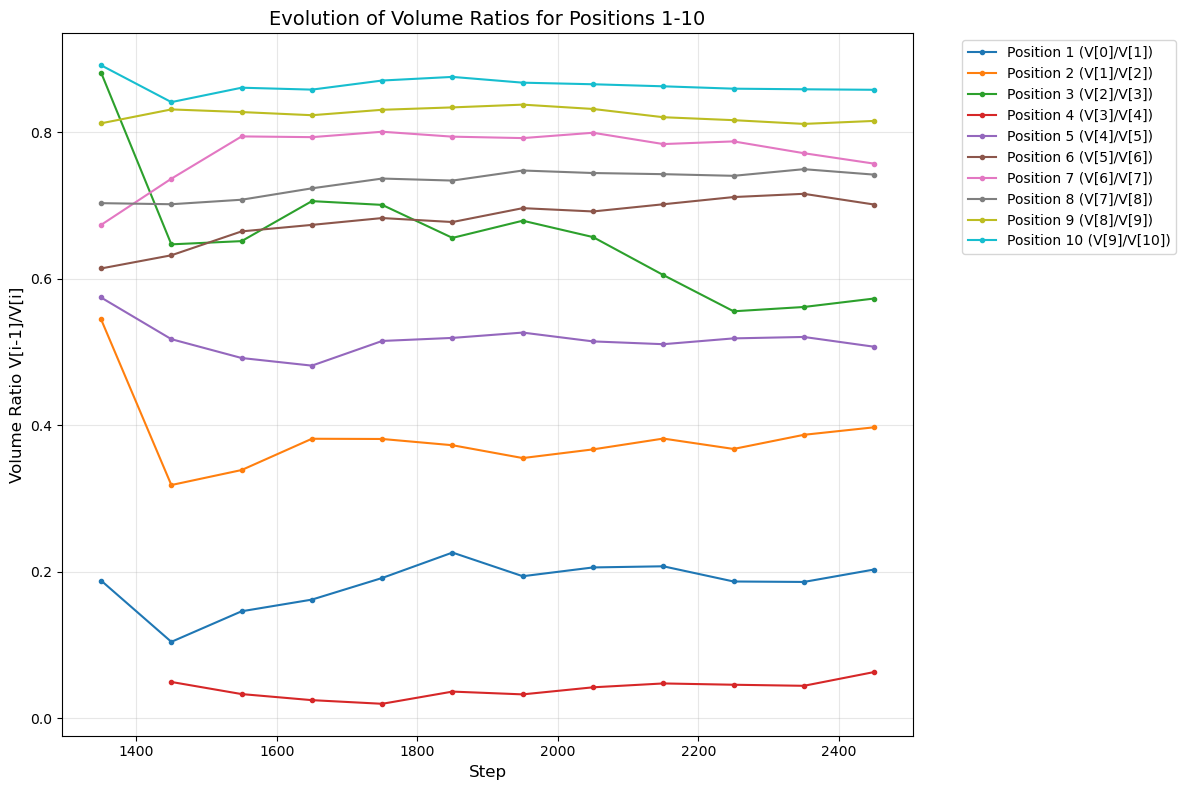


=== Volume of Each Subset Relative to Total Volume ===
V[i]/V_total = Volume of {x: f(x) <= y_i} / Total Parameter Space Volume

Using position 48 as maximum (V_total)

Position   Threshold y_i   V[i]/V_total    Percentage  
------------------------------------------------------------
0          1.000000e+00    1.570278e-04    0.0157      %
1          2.000000e+00    7.637539e-04    0.0764      %
2          3.000000e+00    1.868282e-03    0.1868      %
3          4.000000e+00    3.298521e-03    0.3299      %
4          5.000000e+00    5.425199e-02    5.4252      %
5          6.000000e+00    1.086779e-01    10.8678     %
6          7.000000e+00    1.581459e-01    15.8146     %
7          8.000000e+00    2.107488e-01    21.0749     %
8          9.000000e+00    2.851039e-01    28.5104     %
9          1.000000e+01    3.525024e-01    35.2502     %
10         1.100000e+01    4.091253e-01    40.9125     %
11         1.200000e+01    4.566131e-01    45.6613     %
12         1.300000e+01    5.

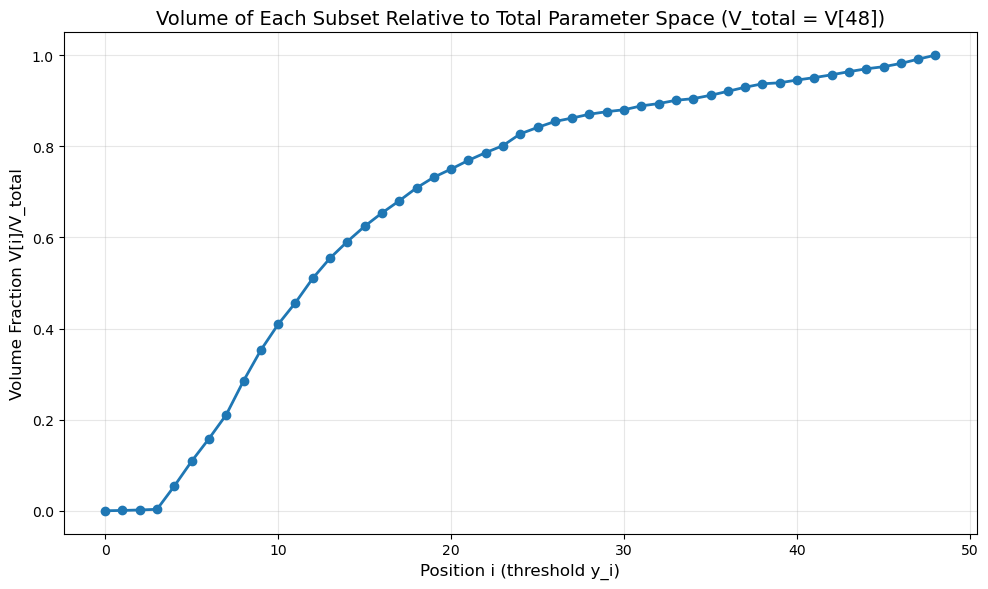

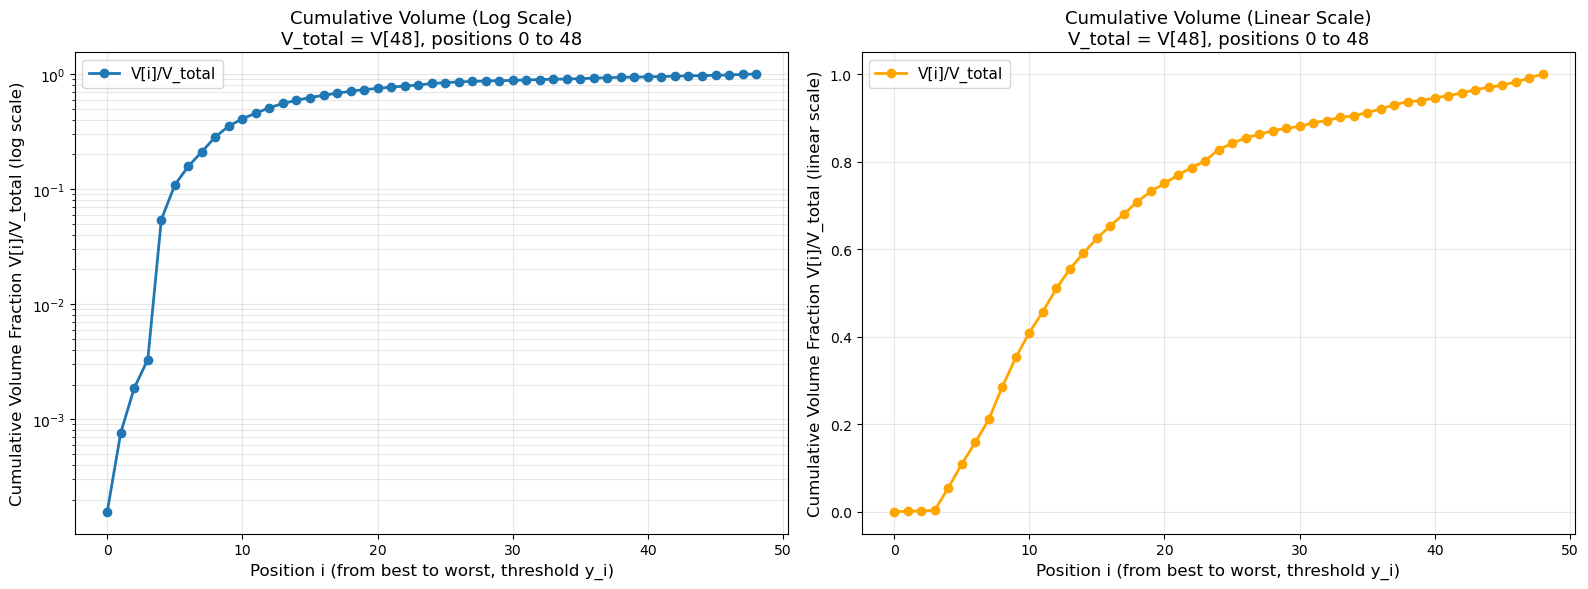

In [64]:
# ============================================================================
# === PLOT VOLUME RATIO EVOLUTION FOR POSITIONS 1-10 ===
# ============================================================================

if is_burned_in and len(volume_ratio_history) > 0:
    # Extract data for positions 1-10
    positions_to_plot = list(range(1, 11))  # Positions 1-10
    
    plt.figure(figsize=(12, 8))
    
    for pos in positions_to_plot:
        if pos < len(volume_ratio_history[0][1]):
            steps = [item[0] for item in volume_ratio_history]
            ratios = [item[1][pos] if item[1][pos] > 0 else np.nan for item in volume_ratio_history]
            plt.plot(steps, ratios, marker='o', label=f'Position {pos} (V[{pos-1}]/V[{pos}])', markersize=3)
    
    plt.xlabel('Step', fontsize=12)
    plt.ylabel('Volume Ratio V[i-1]/V[i]', fontsize=12)
    plt.title('Evolution of Volume Ratios for Positions 1-10', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# === COMPUTE AND PRINT VOLUME OF EACH SUBSET RELATIVE TO TOTAL VOLUME ===
# ============================================================================

if is_burned_in:
    print("\n=== Volume of Each Subset Relative to Total Volume ===")
    print("V[i]/V_total = Volume of {x: f(x) <= y_i} / Total Parameter Space Volume")
    print()
    
    # Find the maximum position with valid volume ratio data
    max_valid_pos = 0
    for i in range(1, len(volume_ratios)):
        if volume_ratios[i] > 0:
            max_valid_pos = i
    
    print(f"Using position {max_valid_pos} as maximum (V_total)")
    print()
    
    # Compute V[i]/V_total iteratively
    # V[i]/V_total = product of ratios from i+1 to max_valid_pos
    # Since V[i-1]/V[i] = ratio[i], we have:
    # V[0]/V[1] = ratio[1]
    # V[1]/V[2] = ratio[2]
    # ...
    # V[max_valid_pos-1]/V[max_valid_pos] = ratio[max_valid_pos]
    # So: V[i]/V[max_valid_pos] = ratio[i+1] * ratio[i+2] * ... * ratio[max_valid_pos]
    # Since V[max_valid_pos] = V_total, we have: V[i]/V_total = product from i+1 to max_valid_pos
    
    volume_fractions = np.full(N_Vec + 1, np.nan)
    
    # Start from the worst position (max_valid_pos): V[max_valid_pos]/V_total = 1.0
    volume_fractions[max_valid_pos] = 1.0
    
    # Work backwards: compute V[i]/V_total for i from max_valid_pos-1 down to 0
    for i in range(max_valid_pos - 1, -1, -1):
        # V[i]/V_total = product of ratios from i+1 to max_valid_pos
        product = 1.0
        for j in range(i + 1, max_valid_pos + 1):
            if j < len(volume_ratios) and volume_ratios[j] > 0:
                product *= volume_ratios[j]
            else:
                product = np.nan
                break
        volume_fractions[i] = product
    
    # Print results
    print(f"{'Position':<10} {'Threshold y_i':<15} {'V[i]/V_total':<15} {'Percentage':<12}")
    print("-" * 60)
    for i in range(max_valid_pos + 1):
        if not np.isnan(volume_fractions[i]):
            percentage = volume_fractions[i] * 100
            print(f"{i:<10} {bin_thresholds[i]:<15.6e} {volume_fractions[i]:<15.6e} {percentage:<12.4f}%")
        else:
            print(f"{i:<10} {bin_thresholds[i]:<15.6e} {'N/A':<15} {'N/A':<12}")
    
    # Also plot volume fractions
    plt.figure(figsize=(10, 6))
    valid_indices = [i for i in range(max_valid_pos + 1) if not np.isnan(volume_fractions[i])]
    valid_fractions = [volume_fractions[i] for i in valid_indices]
    plt.plot(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Position i (threshold y_i)', fontsize=12)
    plt.ylabel('Volume Fraction V[i]/V_total', fontsize=12)
    plt.title(f'Volume of Each Subset Relative to Total Parameter Space (V_total = V[{max_valid_pos}])', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Cumulative volume plot: side by side log and linear
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    valid_indices = [i for i in range(max_valid_pos + 1) if not np.isnan(volume_fractions[i])]
    valid_fractions = [volume_fractions[i] for i in valid_indices]
    
    # Left plot: Log scale
    ax1.semilogy(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6, label='V[i]/V_total')
    ax1.set_xlabel('Position i (from best to worst, threshold y_i)', fontsize=12)
    ax1.set_ylabel('Cumulative Volume Fraction V[i]/V_total (log scale)', fontsize=12)
    ax1.set_title(f'Cumulative Volume (Log Scale)\nV_total = V[{max_valid_pos}], positions 0 to {max_valid_pos}', fontsize=13)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend(fontsize=11)
    
    # Right plot: Linear scale
    ax2.plot(valid_indices, valid_fractions, marker='o', linewidth=2, markersize=6, label='V[i]/V_total', color='orange')
    ax2.set_xlabel('Position i (from best to worst, threshold y_i)', fontsize=12)
    ax2.set_ylabel('Cumulative Volume Fraction V[i]/V_total (linear scale)', fontsize=12)
    ax2.set_title(f'Cumulative Volume (Linear Scale)\nV_total = V[{max_valid_pos}], positions 0 to {max_valid_pos}', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)
    
    # Add threshold annotations if not too many points
    if len(valid_indices) <= 20:
        step = max(1, len(valid_indices)//10)
        for idx in valid_indices[::step]:
            frac_idx = valid_indices.index(idx)
            # Log plot annotations
            ax1.annotate(f'y={bin_thresholds[idx]:.1f}', 
                        xy=(idx, valid_fractions[frac_idx]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
            # Linear plot annotations
            ax2.annotate(f'y={bin_thresholds[idx]:.1f}', 
                        xy=(idx, valid_fractions[frac_idx]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

Preparing data for visualization...
  Total steps: 2501
  Steps with valid data: 2501
  First valid step: 0
  Best f value trajectory: 2501 points

Computing PCA for trajectory visualization...
✓ PCA complete
  Explained variance ratio: [0.50622894 0.21727868 0.13384357]
  Total explained variance: 0.8574
Simulating with first and last parameters...
✓ Simulations complete


/tmp/ipykernel_470001/2323879531.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


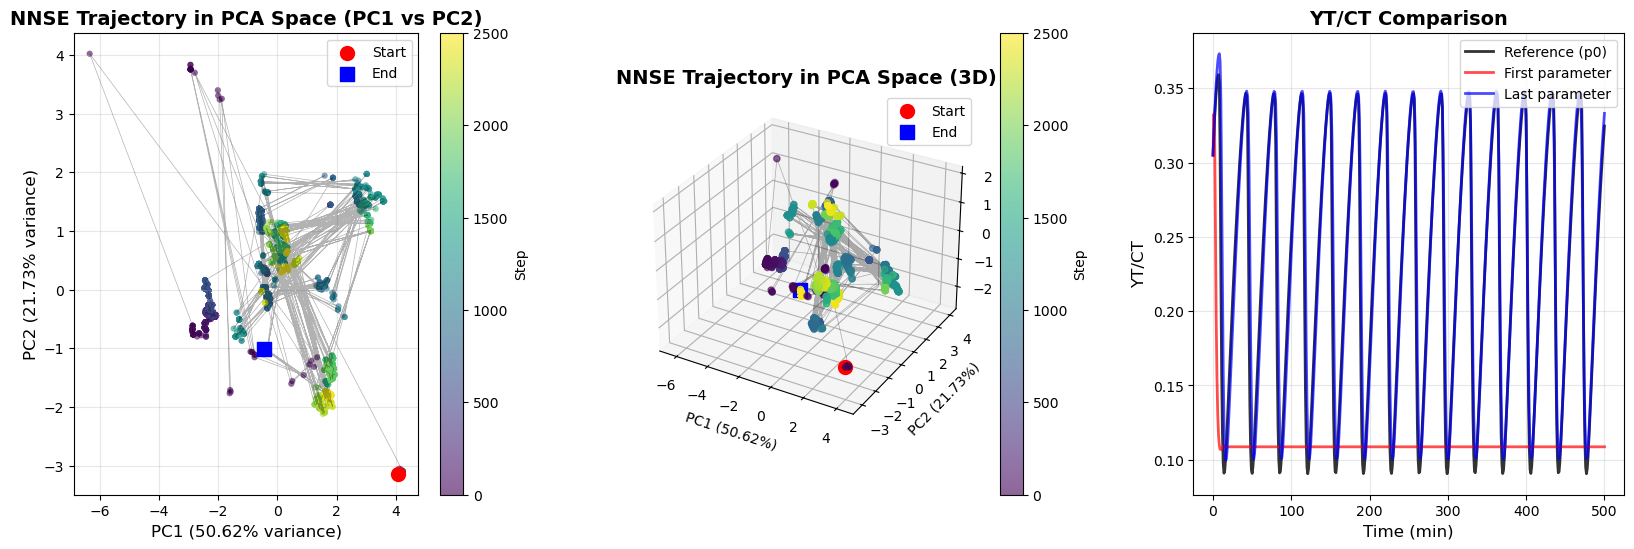


Plotting distribution of squared differences...
  Valid values: 119309/125050
  Mean: 1.063565e+01
  Median: 9.005272e+00
  Min: 9.969989e-02
  Max: 4.879206e+01


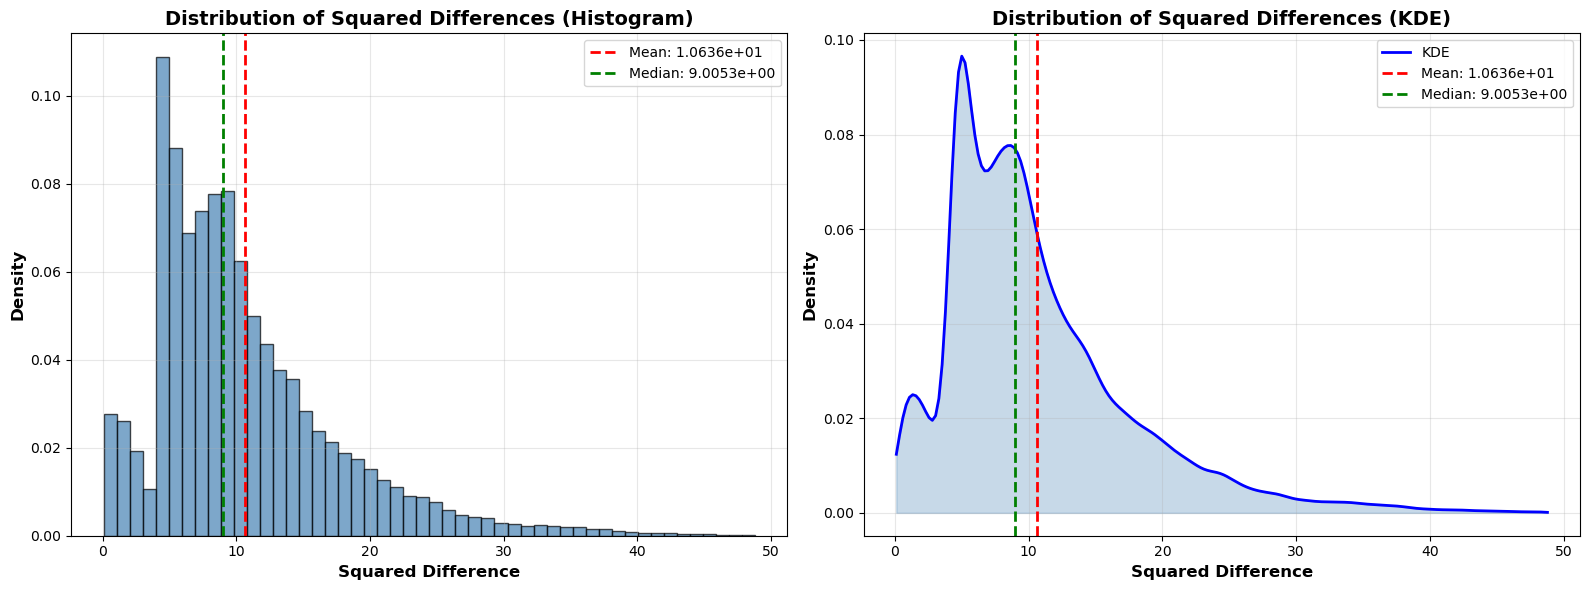

✓ Visualization complete


In [59]:
# ============================================================================
# === VISUALIZATION: PCA TRAJECTORY AND DISTRIBUTIONS ===
# ============================================================================

from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

print("Preparing data for visualization...")

# Convert to numpy arrays, handling None values
# For X: use np.nan where None, for fX: use np.nan where None
all_X_array = np.array([[x if x is not None else np.nan * np.ones(n_params) for x in step_X] for step_X in all_X])
all_fX_array = np.array([[fx if fx is not None else np.nan for fx in step_fX] for step_fX in all_fX])

# Extract the best vector at each step
# Since vectors are sorted by f value, find the first non-NaN value (best available)
# This handles the case where x0 might be empty for many steps
trajectory = []
squared_diffs = []
step_indices = []  # Keep track of which steps had valid data

for step_idx in range(len(all_X_array)):
    # Find the first non-NaN (best) vector at this step
    for pos_idx in range(n):
        if not np.isnan(all_fX_array[step_idx, pos_idx]):
            trajectory.append(all_X_array[step_idx, pos_idx])
            squared_diffs.append(all_fX_array[step_idx, pos_idx])
            step_indices.append(step_idx)
            break  # Found the best available vector, move to next step

trajectory = np.array(trajectory)
squared_diffs = np.array(squared_diffs)
step_indices = np.array(step_indices)

print(f"  Total steps: {len(all_X_array)}")
print(f"  Steps with valid data: {len(trajectory)}")
print(f"  First valid step: {step_indices[0] if len(step_indices) > 0 else 'None'}")
print(f"  Best f value trajectory: {len(squared_diffs)} points")

# ============================================================================
# === PCA TRAJECTORY PLOT ===
# ============================================================================

print("\nComputing PCA for trajectory visualization...")

# Normalize trajectory for PCA (use standardized parameters)
trajectory_normalized = (trajectory - trajectory.mean(axis=0)) / (trajectory.std(axis=0) + 1e-10)

# Compute PCA
pca = PCA(n_components=min(3, n_params))
trajectory_pca = pca.fit_transform(trajectory_normalized)

print(f"✓ PCA complete")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Total explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# Simulate with first and last parameters for YT/CT comparison
print("Simulating with first and last parameters...")
P_first = trajectory[0]  # Best parameter vector at step 0
P_last = trajectory[-1]  # Best parameter vector at final step

# Convert to parameter dictionaries
p_first = copy.deepcopy(p0)
p_last = copy.deepcopy(p0)
for i, name in enumerate(param_names):
    p_first[name] = P_first[i]
    p_last[name] = P_last[i]

# Simulate
t_first, y_first = simulate_at_params(p_first, t_eval)
YT_first, M_first = compute_obs(y_first)
t_last, y_last = simulate_at_params(p_last, t_eval)
YT_last, M_last = compute_obs(y_last)

print("✓ Simulations complete")

# Create figure with 3 subplots
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Plot 2D PCA trajectory
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], 
                     c=range(len(trajectory_pca)), cmap='viridis', 
                     s=20, alpha=0.6, edgecolors='none')
ax1.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], 'k-', alpha=0.3, linewidth=0.5)
ax1.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], 
           color='red', s=100, marker='o', label='Start', zorder=5)
ax1.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], 
           color='blue', s=100, marker='s', label='End', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax1.set_title('NNSE Trajectory in PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Step')

# Second subplot: 3D plot or squared difference over time
if trajectory_pca.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    scatter2 = ax2.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2],
                         c=range(len(trajectory_pca)), cmap='viridis', s=20, alpha=0.6)
    ax2.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2], 
            'k-', alpha=0.3, linewidth=0.5)
    ax2.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], trajectory_pca[0, 2],
               color='red', s=100, marker='o', label='Start')
    ax2.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], trajectory_pca[-1, 2],
               color='blue', s=100, marker='s', label='End')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
    ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})', fontsize=10)
    ax2.set_title('NNSE Trajectory in PCA Space (3D)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    plt.colorbar(scatter2, ax=ax2, label='Step')
else:
    # If only 2 components, show squared difference over time
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(range(len(squared_diffs)), squared_diffs, 'b-', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Step', fontsize=12)
    ax2.set_ylabel('Squared Difference', fontsize=12)
    ax2.set_title('Best Squared Difference Over Time', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

# Third subplot: YT/CT comparison
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(t0, YT0, 'k-', lw=2, label='Reference (p0)', alpha=0.8)
ax3.plot(t_first, YT_first, 'r-', lw=2, label='First parameter', alpha=0.7)
ax3.plot(t_last, YT_last, 'b-', lw=2, label='Last parameter', alpha=0.7)
ax3.set_xlabel('Time (min)', fontsize=12)
ax3.set_ylabel('YT/CT', fontsize=12)
ax3.set_title('YT/CT Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# === DISTRIBUTION OF SQUARED DIFFERENCES ===
# ============================================================================

print("\nPlotting distribution of squared differences...")

# For distribution, use all squared differences from all vectors at all steps
# This gives a better picture of the full distribution
squared_diffs_all = all_fX_array.flatten()  # All function values from all vectors

# Filter out infinite values
valid_mask = np.isfinite(squared_diffs_all)
squared_diffs_valid = squared_diffs_all[valid_mask]

print(f"  Valid values: {np.sum(valid_mask)}/{len(squared_diffs_all)}")
print(f"  Mean: {np.mean(squared_diffs_valid):.6e}")
print(f"  Median: {np.median(squared_diffs_valid):.6e}")
print(f"  Min: {np.min(squared_diffs_valid):.6e}")
print(f"  Max: {np.max(squared_diffs_valid):.6e}")

# Create distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with linear bins
ax1 = axes[0]
n_bins_hist = 50
# Use linear bins from min to max
counts, bins_hist, patches = ax1.hist(squared_diffs_valid, bins=n_bins_hist, 
                                      edgecolor='black', alpha=0.7, color='steelblue',
                                      density=True)
ax1.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
ax1.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
           linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
ax1.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Squared Differences (Histogram)', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Kernel density estimate (KDE) with linear scale
ax2 = axes[1]
if len(squared_diffs_valid) > 1:
    # Use linear KDE (not log-transformed)
    kde = gaussian_kde(squared_diffs_valid)
    x_kde = np.linspace(squared_diffs_valid.min(), squared_diffs_valid.max(), 200)
    density = kde(x_kde)
    ax2.plot(x_kde, density, 'b-', linewidth=2, label='KDE')
    ax2.fill_between(x_kde, 0, density, alpha=0.3, color='steelblue')
    ax2.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
    ax2.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
    ax2.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Not enough data for KDE', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization complete")
